<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_mini_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel reservations

[link text](https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset/code)
- 주제 : 호텔 예약 분류 예측
  - 온라인 호텔 예약 시스템으로 인해 상당수의 호텔 예약은 취소되거나 노쇼(no-show) 발생 가능
  - 취소로 인한 패널티가 작기에 호텔 입장에서는 수익 감소 가능성 존재
  - 호텔 예약시, 취소하거나 그대로 이행할 가능성 예측

전처리 관련

- XGBoost
[link text](https://www.kaggle.com/code/truptichudasama/xgboost-in-action-confusion-classfication-matrix)

- EDA
[link text](https://www.kaggle.com/code/gorkembakir/hotel-reservations-eda)

In [86]:
!pip install catboost

In [87]:
!pip install optuna

In [88]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# **1. DATA 탐색 - EDA**

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
data = pd.read_csv('/content/drive/MyDrive/ESAA_OB_pj/Hotel Reservations.csv')

In [91]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

- null X
- column = 19개
  - no_of_adults : 예약에 포함된 성인 인원 수
  - no_of_children : 어린이 인원 수
  - no_of_weekend_nights : 숙박 기간 중 주말에 머무는 밤 수
  - no_of_week_nights : 숙박 기간 중 평일에 머무는 밤 수
  - type_of_meal_plan : 예약한 식사 플랜 종류
  - required_car_parking_space : 주차 공간이 필요한지 여부를 나타내는 변수
  - room_type_reserved : 고객이 예약한 객실 유형
  - lead_time : 예약한 시점부터 실제 체크인 날짜까지 남은 기간
  - arrival_year : 도착(체크인) 연도
  - arrival_month : 도착(체크인) 월
  - arrival_date : 도착(체크인) 일(day)
  - market_segment_type : 예약이 들어온 시장 세그먼트(고객 유형/예약 경로)
  - repeated_guest : 재방문 고객인지 여부
    - 0이면 처음 온 고객, 1이면 이전에도 이용한 고객
  - no_of_previous_cancellations : 고객이 과거에 했던 예약 중 취소한 횟수
  - no_of_previous_bookings_not_canceled : 고객이 과거에 했던 예약 중 취소하지 않고 실제 이용한 횟수
  - avg_price_per_room : 객실 1개당 평균 가격
  - no_of_special_requests : 고객이 한 특별 요청의 개수
  - booking_status : 예약의 최종 상태

In [93]:
data.describe(include='all').T   # 수치형뿐 아니라 문자형(object)도 함께 요약

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN36275,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.0,NaN,NaN,NaN,1.844962,0.518715,0.0,2.0,2.0,2.0,4.0
no_of_children,36275.0,NaN,NaN,NaN,0.105279,0.402648,0.0,0.0,0.0,0.0,10.0
no_of_weekend_nights,36275.0,NaN,NaN,NaN,0.810724,0.870644,0.0,0.0,1.0,2.0,7.0
no_of_week_nights,36275.0,NaN,NaN,NaN,2.2043,1.410905,0.0,1.0,2.0,3.0,17.0
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.0,NaN,NaN,NaN,0.030986,0.173281,0.0,0.0,0.0,0.0,1.0
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.0,NaN,NaN,NaN,85.232557,85.930817,0.0,17.0,57.0,126.0,443.0
arrival_year,36275.0,NaN,NaN,NaN,2017.820427,0.383836,2017.0,2018.0,2018.0,2018.0,2018.0


- count: 결측치 제외 개수
- unique: 고유값 개수
- top: 가장 많이 나온 값
- freq: 그 값의 빈도수

< object 열 파악 >

- type_of_meal_plan
- room_type_reserved
- market_segment_type
- booking_status

In [94]:
data['type_of_meal_plan'].value_counts()

,count
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


In [95]:
data['room_type_reserved'].value_counts()

,count
room_type_reserved,
Room_Type 1,28130
Room_Type 4,6057
Room_Type 6,966
Room_Type 2,692
Room_Type 5,265
Room_Type 7,158
Room_Type 3,7


In [96]:
data['market_segment_type'].value_counts()

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


In [97]:
data['booking_status'].value_counts()

,count
booking_status,
Not_Canceled,24390
Canceled,11885


## < 변수 분리 >

In [98]:
# 4개
categorical_features  = ['type_of_meal_plan','room_type_reserved','market_segment_type', 'booking_status']

In [99]:
# 14개
numerical_features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                      'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date',
                      'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
                      'avg_price_per_room', 'no_of_special_requests']

In [100]:
data_features = data[categorical_features + numerical_features]
data_features.head()

,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,Meal Plan 1,Room_Type 1,Offline,Not_Canceled,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0
1,Not Selected,Room_Type 1,Online,Not_Canceled,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1
2,Meal Plan 1,Room_Type 1,Online,Canceled,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0
3,Meal Plan 1,Room_Type 1,Online,Canceled,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0
4,Not Selected,Room_Type 1,Online,Canceled,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0


In [101]:
data_f = data_features.copy()

## < 시각화 >

In [102]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(data_features[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

def bar_plot(variable):

    # get feature
    var = data_features[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

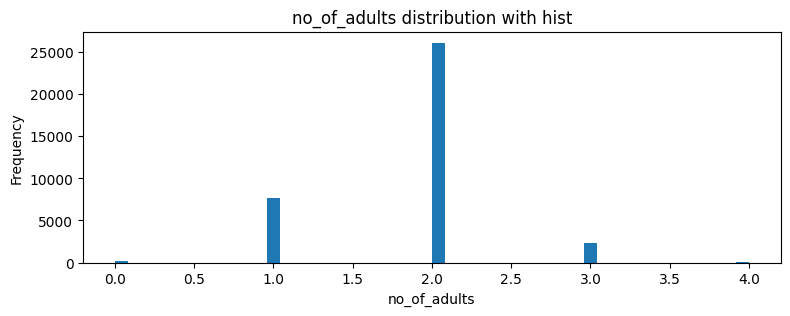

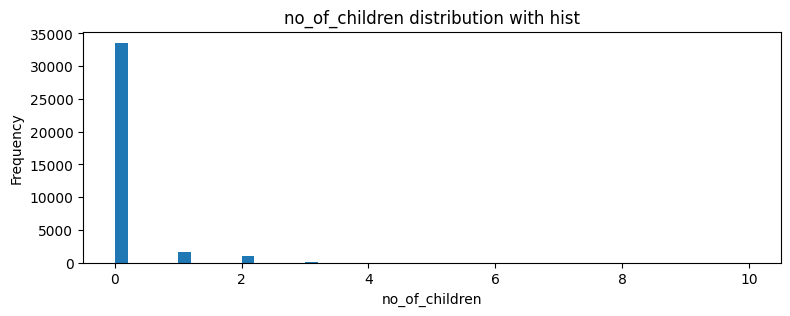

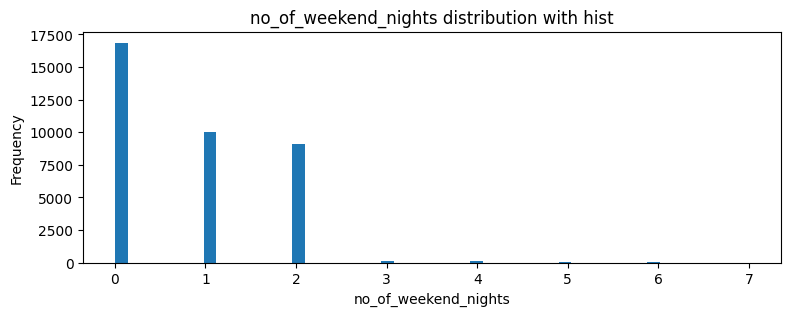

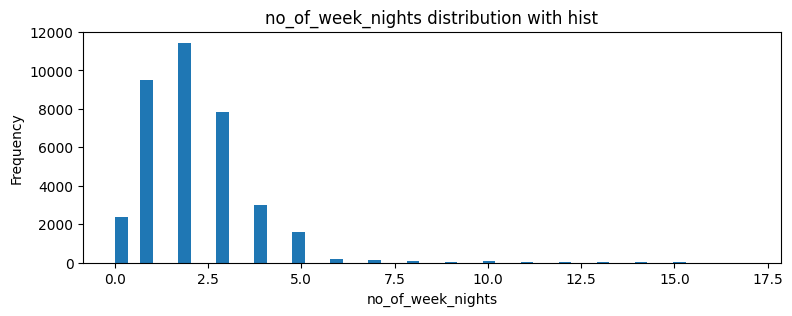

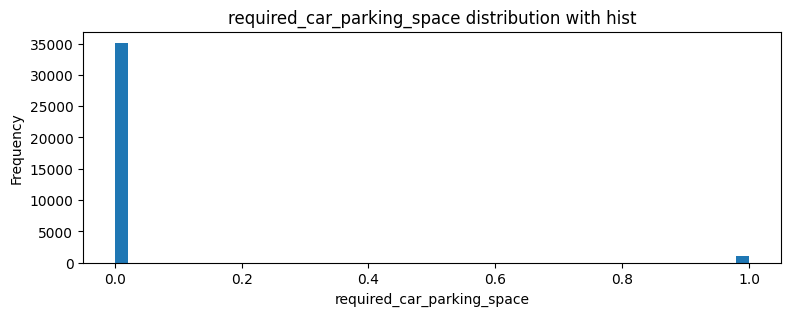

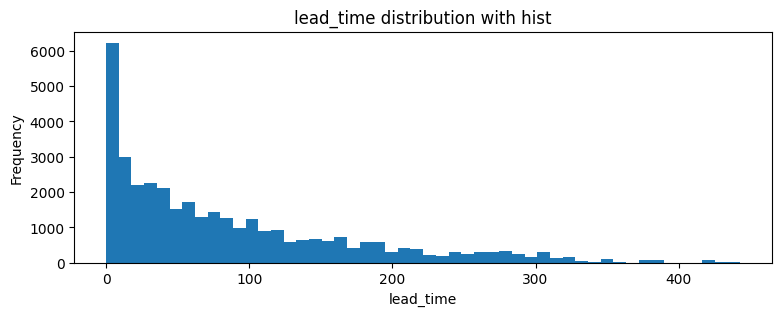

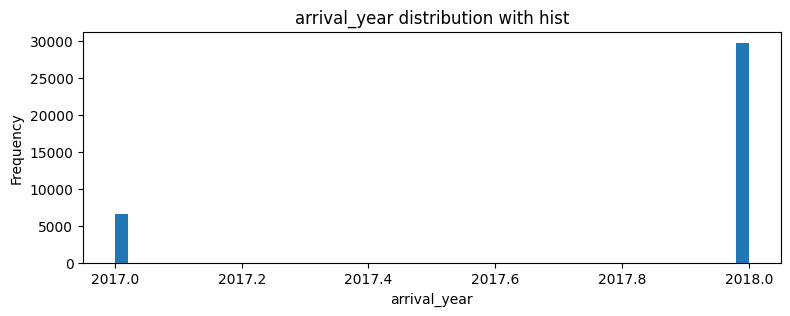

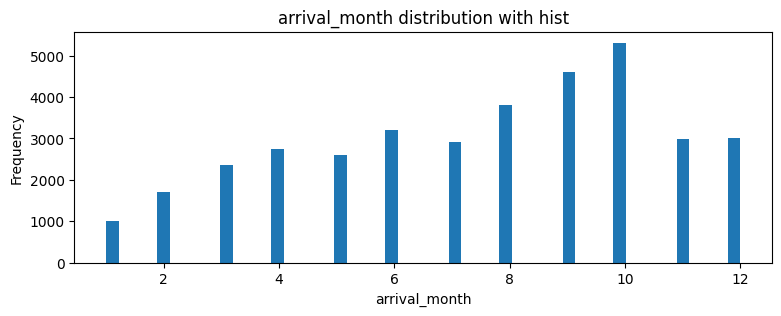

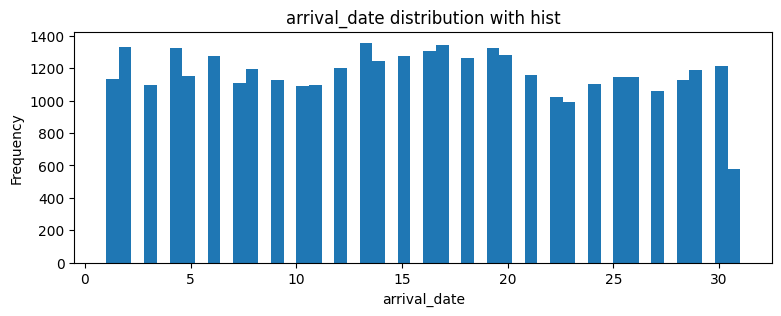

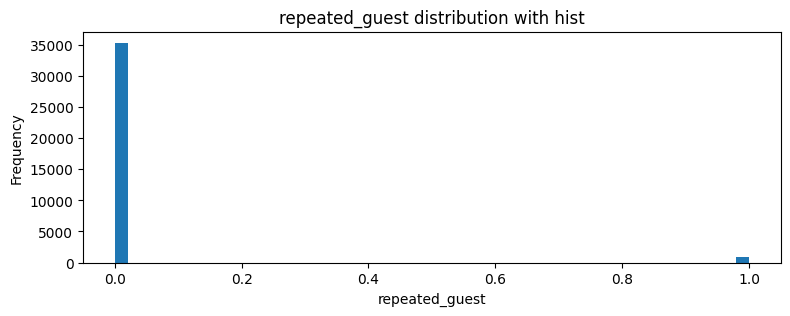

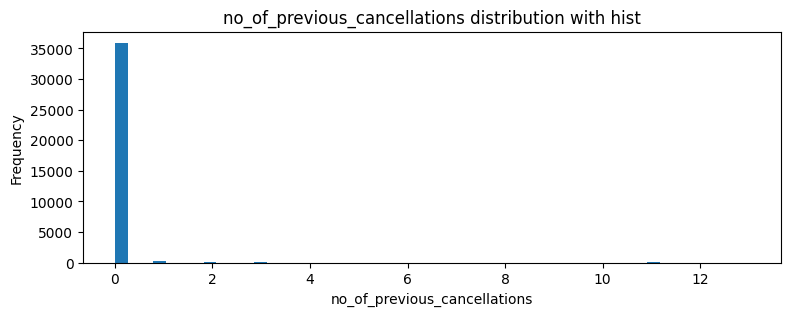

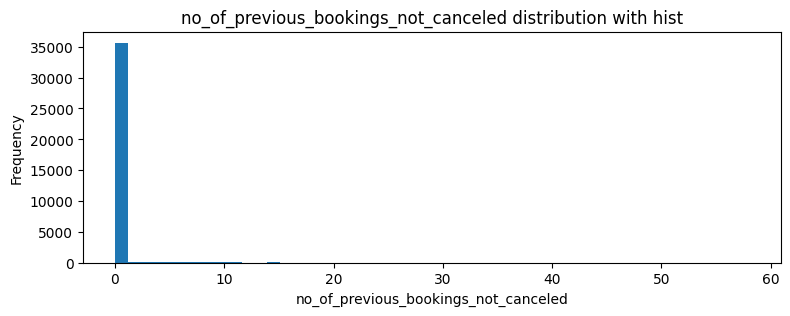

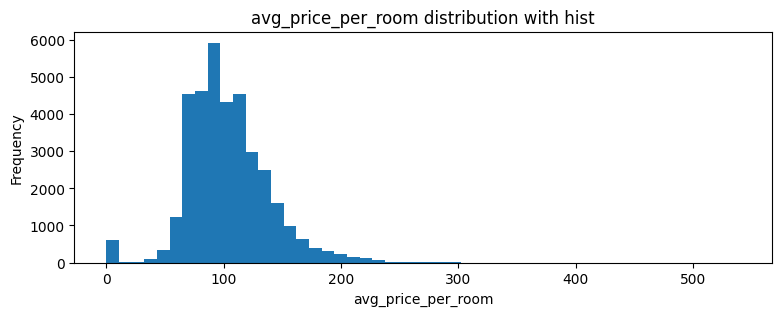

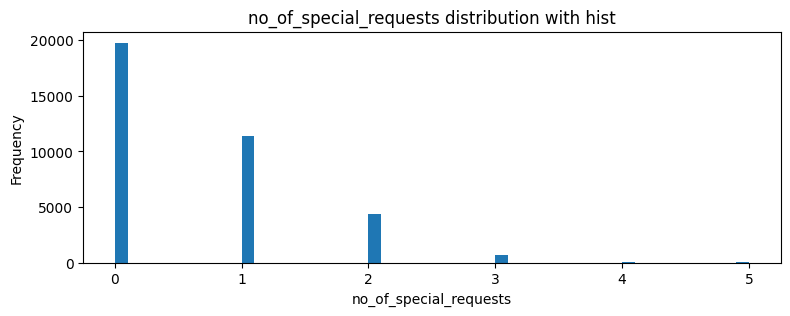

In [103]:
for col in numerical_features:
    plot_hist(col)

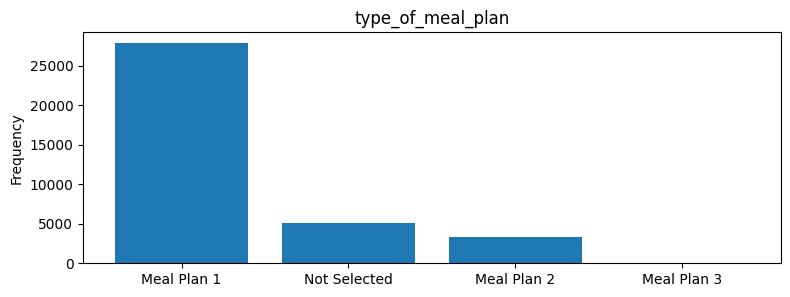

type_of_meal_plan: 
 type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


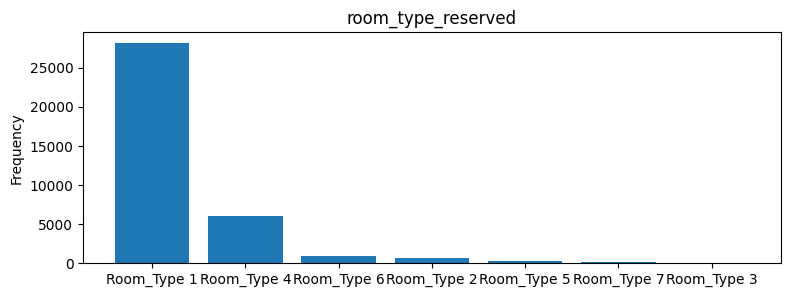

room_type_reserved: 
 room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


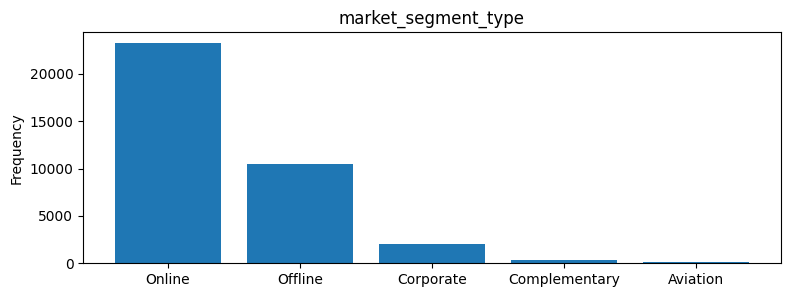

market_segment_type: 
 market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


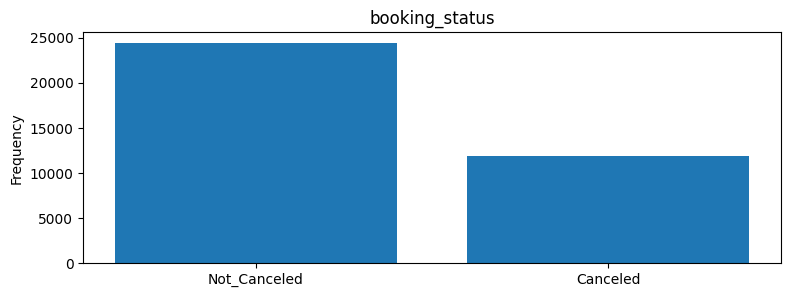

booking_status: 
 booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [104]:
for col in categorical_features:
    bar_plot(col)

## < encoding >

### categorial features

- 원핫 인코딩

In [105]:
# booking_status
data_f['booking_status_encoded'] = data_f['booking_status'].map({'Canceled':0, 'Not_Canceled':1})
data_f.drop(['booking_status'], axis=1, inplace=True)

In [106]:
# 나머지 categorial features one-hot encoding
ohe_columns = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

### numerical features

- 로그 변환 : lead_time, no_of_previous_cancellations, no_of_previous_bookings_not_canceled, avg_price_per_room
- 스케일링 : 0/1 변수 제외 12개



In [107]:
log_columns = ['lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room']

In [108]:
scale_cols = [
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'lead_time',
    'arrival_year',
    'arrival_month',
    'arrival_date',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'no_of_special_requests'
]

- 'avg_price_per_room' 변수는 로버스트 스케일링 적용
  - 이상치에 덜 민감하게 하기 위함

In [109]:
robust_scale_cols = ['avg_price_per_room']

# **2. 예측**

- **Logistic Regression** : 원핫 인코딩, 로그 변환, 스케일링, 다중공선성 제거
- **LightGBM, XGB, Random Forest** : 원핫 인코딩만
- **CatBoost** : raw

> 모델 별 파이프라인 분리

In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
train = pd.read_csv('/content/drive/MyDrive/ESAA_OB_pj/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ESAA_OB_pj/test.csv')
test_solution = pd.read_csv('/content/drive/MyDrive/ESAA_OB_pj/test_solution.csv')

In [112]:
# train 타깃 인코딩
train['booking_status_encoded'] = train['booking_status'].map({'Canceled': 0, 'Not_Canceled': 1})
train.drop(columns=['booking_status'], inplace=True)

# test_solution 타깃 인코딩
test_solution['booking_status_encoded'] = test_solution['booking_status'].map({'Canceled': 0, 'Not_Canceled': 1})
test_solution.drop(columns=['booking_status'], inplace=True)

# 학습용 데이터
X_train = train.drop(columns=['booking_status_encoded', 'Booking_ID'])
y_train = train['booking_status_encoded']

# 테스트용 입력 데이터
X_test = test.drop(columns=['Booking_ID'])

# 테스트용 정답 데이터
y_test = test_solution['booking_status_encoded']

## Logistic Regression

In [113]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# 1) 로그 변환
for col in log_columns:
    X_train_lr[col] = np.log1p(X_train_lr[col])
    X_test_lr[col] = np.log1p(X_test_lr[col])

# 2) 원핫 인코딩
X_train_lr = pd.get_dummies(X_train_lr, columns=ohe_columns, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, columns=ohe_columns, drop_first=True)

# 3) 컬럼 맞추기
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# 4) 스케일링
scaler = StandardScaler()
X_train_lr[scale_cols] = scaler.fit_transform(X_train_lr[scale_cols])
X_test_lr[scale_cols] = scaler.transform(X_test_lr[scale_cols])

robust_scaler = RobustScaler()
X_train_lr[robust_scale_cols] = robust_scaler.fit_transform(X_train_lr[robust_scale_cols])
X_test_lr[robust_scale_cols] = robust_scaler.transform(X_test_lr[robust_scale_cols])

### modeling

In [114]:
lr = LogisticRegression()
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)
y_pred_proba_lr = lr.predict_proba(X_test_lr)[:, 1]

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.80289455547898
Precision: 0.830394787274818
Recall: 0.8882738827388273
F1-score: 0.8583597464342314
ROC-AUC: 0.8586657911173138

Confusion Matrix
[[1492  885]
 [ 545 4333]]

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.63      0.68      2377
           1       0.83      0.89      0.86      4878

    accuracy                           0.80      7255
   macro avg       0.78      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255



### strong correlation drop - 상관계수 & VIF

**상관계수**

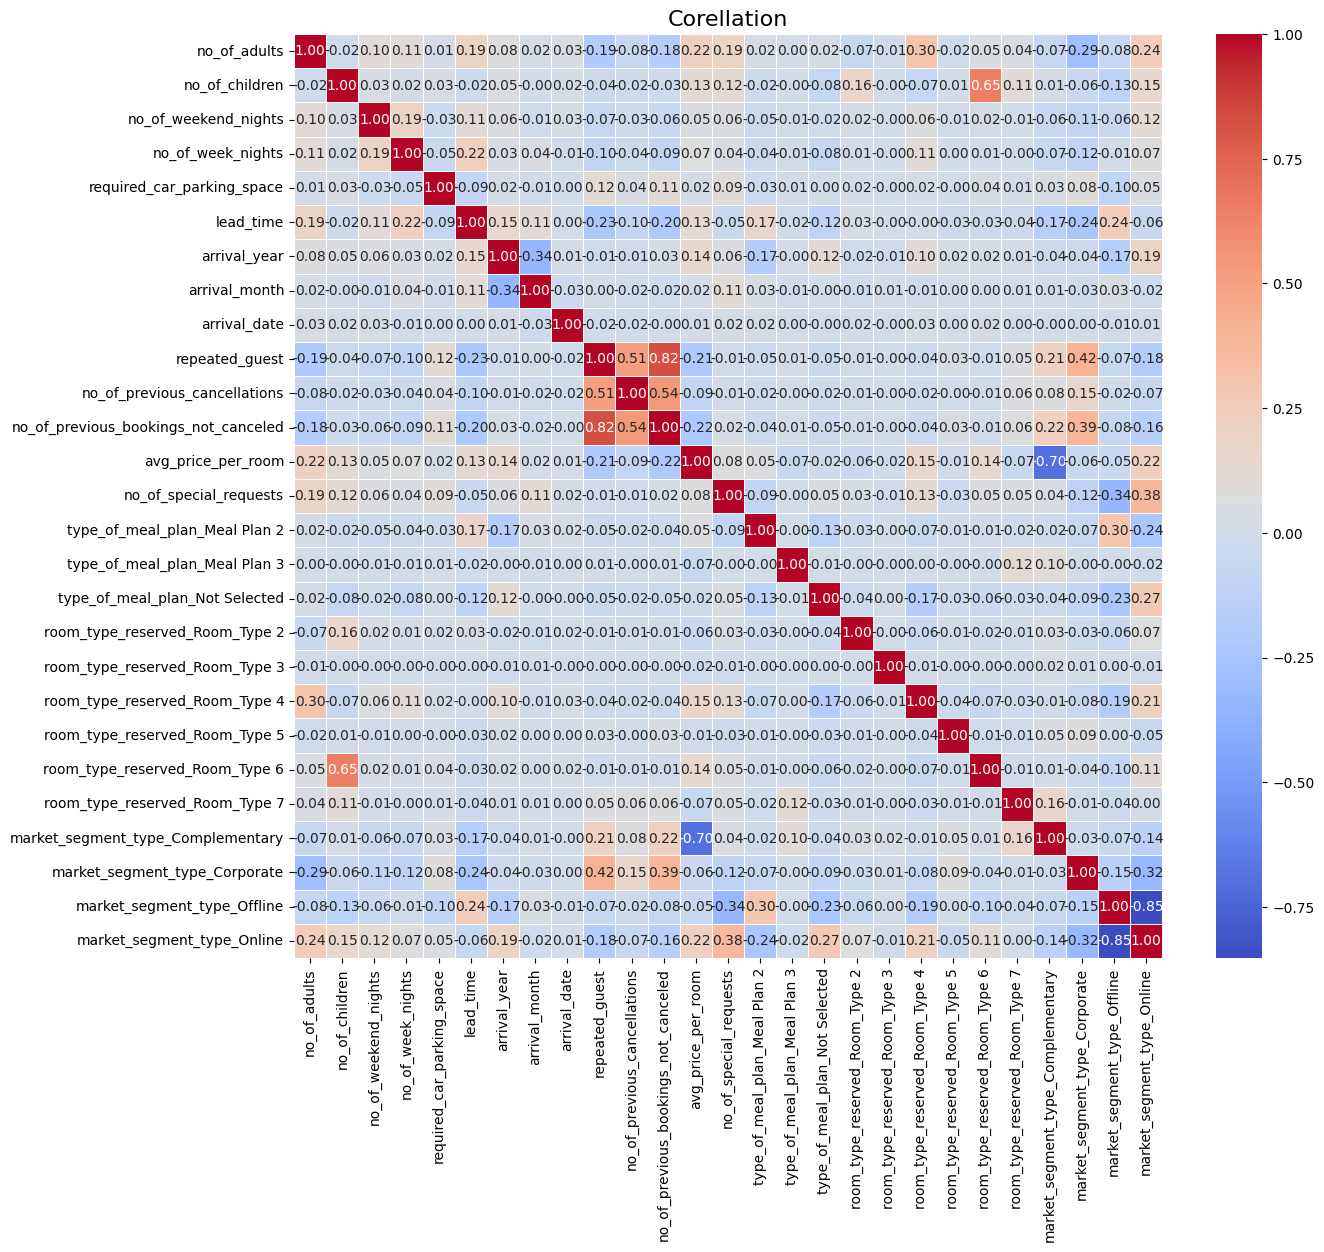

In [116]:
correlation_matrix = X_train_lr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

plt.title('Corellation', fontsize=16)
plt.show()

- strong relationship이 보이면, column 다시 drop 후, 스케일링

< strong relationship >
- repeated_guest ↔ no_of_previous_bookings_not_canceled
- market_segment_type_Offline ↔ market_segment_type_Online
- no_of_previous_cancellations ↔ repeated_guest
- no_of_previous_cancellations ↔ no_of_previous_bookings_not_canceled
- no_of_previous_cancellations ↔ no_of_previous_bookings_not_canceled

**VIF**

In [117]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = add_constant(X_train_lr)
X_vif = X_vif.astype(float)

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df

,feature,VIF
0,const,294.286000
27,market_segment_type_Online,67.722870
26,market_segment_type_Offline,61.112394
25,market_segment_type_Corporate,16.159452
24,market_segment_type_Complementary,5.304353
12,no_of_previous_bookings_not_canceled,3.433674
10,repeated_guest,3.362854
13,avg_price_per_room,2.356421
2,no_of_children,1.941398
22,room_type_reserved_Room_Type 6,1.849222


- market_segment_type_ 손봐야 할 듯
  - 원핫 인코딩 때문에 이렇게 보이는 거긴 함
  - 그래도 한번 손보고 모델 돌려보기
    - 변수 묶기 : market_segment_type 재분류해서 원핫 인코딩 다시

In [118]:
def simplify_market_segment(x):
    if x in ['Online', 'Offline']:
        return x
    else:
        return 'Others'

In [119]:
X_train_lr2 = X_train.copy()
X_test_lr2 = X_test.copy()

for col in log_columns:
    X_train_lr2[col] = np.log1p(X_train_lr2[col])
    X_test_lr2[col] = np.log1p(X_test_lr2[col])

In [120]:
X_train_lr2['market_segment_type'] = X_train_lr2['market_segment_type'].apply(simplify_market_segment)
X_test_lr2['market_segment_type'] = X_test_lr2['market_segment_type'].apply(simplify_market_segment)

In [121]:
X_train_lr2 = pd.get_dummies(X_train_lr2, columns=ohe_columns, drop_first=True)
X_test_lr2 = pd.get_dummies(X_test_lr2, columns=ohe_columns, drop_first=True)

X_train_lr2, X_test_lr2 = X_train_lr2.align(X_test_lr2, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_lr2[scale_cols] = scaler.fit_transform(X_train_lr2[scale_cols])
X_test_lr2[scale_cols] = scaler.transform(X_test_lr2[scale_cols])

### modeling

In [122]:
lr2 = LogisticRegression()
lr2.fit(X_train_lr2, y_train)

y_pred_lr2 = lr2.predict(X_test_lr2)
y_pred_proba_lr2 = lr2.predict_proba(X_test_lr2)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [123]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr2))
print("Precision:", precision_score(y_test, y_pred_lr2))
print("Recall:", recall_score(y_test, y_pred_lr2))
print("F1-score:", f1_score(y_test, y_pred_lr2))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr2))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr2))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr2))

Accuracy: 0.7998621640248105
Precision: 0.8282866998850135
Recall: 0.8860188601886019
F1-score: 0.8561806656101426
ROC-AUC: 0.8581126219339601

Confusion Matrix
[[1481  896]
 [ 556 4322]]

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      2377
           1       0.83      0.89      0.86      4878

    accuracy                           0.80      7255
   macro avg       0.78      0.75      0.76      7255
weighted avg       0.80      0.80      0.80      7255



- 원래 데이터셋이랑 X_train_lr2 데이터셋 중, 원래 데이터셋 성능이 더 좋음
  - 아주 아주 미세하긴 함
- 따라서 하이퍼파라미터 설정을 원래 데이터셋으로 진행

In [124]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 3, 5, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_lr, y_train)

print("Best Params:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Params: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.8534036249851111


In [125]:
grid_lr_best = grid_lr.best_estimator_
y_pred_lr_best = grid_lr_best.predict(X_test_lr)
y_pred_lr_best_proba = grid_lr_best.predict_proba(X_test_lr)[:, 1]

In [126]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_best))
print("Precision:", precision_score(y_test, y_pred_lr_best))
print("Recall:", recall_score(y_test, y_pred_lr_best))
print("F1-score:", f1_score(y_test, y_pred_lr_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_best_proba))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr_best))

Accuracy: 0.802343211578222
Precision: 0.8287514318442154
Recall: 0.8899138991389914
F1-score: 0.858244365361803
ROC-AUC: 0.8586334496075294

Confusion Matrix
[[1480  897]
 [ 537 4341]]

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      2377
           1       0.83      0.89      0.86      4878

    accuracy                           0.80      7255
   macro avg       0.78      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255



- 별로 달라진 것 없고 그냥 처음 모델이 제일 나은듯

### 파생 변수 추가

In [127]:
def add_features(df):
    df = df.copy()
    df['total_nights'] = df['no_of_week_nights'] + df['no_of_weekend_nights']
    df['total_guests'] = df['no_of_adults'] + df['no_of_children']
    df['price_per_person'] = df['avg_price_per_room'] / (df['total_guests'] + 1)
    df['weekend_ratio'] = df['no_of_weekend_nights'] / (df['total_nights'] + 1)
    return df

In [128]:
X_train_lr_fe = add_features(X_train)
X_test_lr_fe = add_features(X_test)

In [129]:
for col in log_columns:
    X_train_lr_fe[col] = np.log1p(X_train_lr_fe[col])
    X_test_lr_fe[col] = np.log1p(X_test_lr_fe[col])

X_train_lr_fe = pd.get_dummies(X_train_lr_fe, columns=ohe_columns, drop_first=True)
X_test_lr_fe = pd.get_dummies(X_test_lr_fe, columns=ohe_columns, drop_first=True)

X_train_lr_fe, X_test_lr_fe = X_train_lr_fe.align(X_test_lr_fe, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_lr_fe[scale_cols] = scaler.fit_transform(X_train_lr_fe[scale_cols])
X_test_lr_fe[scale_cols] = scaler.transform(X_test_lr_fe[scale_cols])

In [130]:
lr_fe = LogisticRegression()
lr_fe.fit(X_train_lr_fe, y_train)

y_pred_lr_fe = lr_fe.predict(X_test_lr_fe)
y_pred_proba_lr_fe = lr_fe.predict_proba(X_test_lr_fe)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [131]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_fe))
print("Precision:", precision_score(y_test, y_pred_lr_fe))
print("Recall:", recall_score(y_test, y_pred_lr_fe))
print("F1-score:", f1_score(y_test, y_pred_lr_fe))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr_fe))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr_fe))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr_fe))

Accuracy: 0.8092350103376982
Precision: 0.83531669865643
Recall: 0.8921689216892169
F1-score: 0.8628072957969866
ROC-AUC: 0.8574667404225579

Confusion Matrix
[[1519  858]
 [ 526 4352]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.64      0.69      2377
           1       0.84      0.89      0.86      4878

    accuracy                           0.81      7255
   macro avg       0.79      0.77      0.77      7255
weighted avg       0.81      0.81      0.81      7255



### 중요도 낮은 피처 제거

In [132]:
coef_df = pd.DataFrame({
    'feature': X_train_lr.columns,
    'coef': lr.coef_[0],
    'abs_coef': np.abs(lr.coef_[0])
}).sort_values(by='abs_coef', ascending=False)

coef_df.head(20)

,feature,coef,abs_coef
25,market_segment_type_Offline,2.189808,2.189808
9,repeated_guest,1.744895,1.744895
4,required_car_parking_space,1.583365,1.583365
24,market_segment_type_Corporate,1.429988,1.429988
5,lead_time,-1.366661,1.366661
13,no_of_special_requests,1.162894,1.162894
22,room_type_reserved_Room_Type 7,0.705464,0.705464
12,avg_price_per_room,-0.646347,0.646347
20,room_type_reserved_Room_Type 5,0.615328,0.615328
26,market_segment_type_Online,0.595855,0.595855


In [133]:
coef_df.sort_values(by='abs_coef', ascending=True).head(20)

,feature,coef,abs_coef
7,arrival_month,0.000553,0.000553
0,no_of_adults,-0.014894,0.014894
3,no_of_week_nights,-0.018926,0.018926
8,arrival_date,-0.033546,0.033546
1,no_of_children,-0.056259,0.056259
2,no_of_weekend_nights,-0.071220,0.071220
16,type_of_meal_plan_Not Selected,-0.131029,0.131029
18,room_type_reserved_Room_Type 3,0.138954,0.138954
10,no_of_previous_cancellations,-0.171134,0.171134
11,no_of_previous_bookings_not_canceled,0.234311,0.234311


In [134]:
low_importance_features = coef_df.sort_values(by='abs_coef', ascending=True).head(3)['feature'].tolist()
low_importance_features

['arrival_month', 'no_of_adults', 'no_of_week_nights']

In [135]:
X_train_lr_reduced = X_train_lr.drop(columns=low_importance_features)
X_test_lr_reduced = X_test_lr.drop(columns=low_importance_features)

In [136]:
lr_reduced = LogisticRegression(max_iter=1000, random_state=42)
lr_reduced.fit(X_train_lr_reduced, y_train)

y_pred_lr_reduced = lr_reduced.predict(X_test_lr_reduced)
y_pred_proba_lr_reduced = lr_reduced.predict_proba(X_test_lr_reduced)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr_reduced))
print("Precision:", precision_score(y_test, y_pred_lr_reduced))
print("Recall:", recall_score(y_test, y_pred_lr_reduced))
print("F1-score:", f1_score(y_test, y_pred_lr_reduced))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr_reduced))

Accuracy: 0.8049620951068229
Precision: 0.8318957255127468
Recall: 0.8897088970889709
F1-score: 0.8598315998018822
ROC-AUC: 0.8585935186234487


## LightGBM, XGB, Random Forest

In [137]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

X_train_tree = pd.get_dummies(X_train_tree, columns=ohe_columns, drop_first=True)
X_test_tree = pd.get_dummies(X_test_tree, columns=ohe_columns, drop_first=True)

X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

**트리 모델 평가 함수**

In [138]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = None

    print(f"===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

    if y_pred_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

### modeling - LightGBM

In [139]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(X_train_tree, y_train)

evaluate_model(lgbm_model, X_test_tree, y_test, "LightGBM")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19512, number of negative: 9508
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 29020, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.672364 -> initscore=0.718896
[LightGBM] [Info] Start training from score 0.718896
===== LightGBM =====
Accuracy: 0.8970365265334252
Precision: 0.9073161112206666
Recall: 0.9432144321443214
F1-score: 0.9249170770931752
ROC-AUC: 0.9560915708021195

Confusion Matrix
[[1907  470]
 [ 277 4601]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      2377
           1       0.91      0.94      0.92      4878

    accuracy                      

### 하이퍼파라미터 서치

In [140]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = LGBMClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train_tree,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

In [141]:
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=50)

print("Best LGB Score:", study_lgb.best_value)
print("Best LGB Params:", study_lgb.best_params)

[I 2026-03-27 08:18:36,845] A new study created in memory with name: no-name-ebd3546d-95b1-467c-b77c-c29c36a665be
[I 2026-03-27 08:18:50,469] Trial 0 finished with value: 0.922108202660616 and parameters: {'n_estimators': 338, 'learning_rate': 0.14057557666669665, 'max_depth': 8, 'num_leaves': 60, 'min_child_samples': 20, 'subsample': 0.8138663449982473, 'colsample_bytree': 0.7834751036755142, 'reg_alpha': 0.6930414262037671, 'reg_lambda': 0.03979416667257138}. Best is trial 0 with value: 0.922108202660616.
[I 2026-03-27 08:18:59,736] Trial 1 finished with value: 0.8880494823726058 and parameters: {'n_estimators': 339, 'learning_rate': 0.013705177106623986, 'max_depth': 3, 'num_leaves': 113, 'min_child_samples': 47, 'subsample': 0.8894381964750231, 'colsample_bytree': 0.8118930361683142, 'reg_alpha': 0.30345806476525744, 'reg_lambda': 0.0008916561995480466}. Best is trial 0 with value: 0.922108202660616.
[I 2026-03-27 08:19:07,212] Trial 2 finished with value: 0.9147205573649722 and pa

Best LGB Score: 0.9238191013742281
Best LGB Params: {'n_estimators': 463, 'learning_rate': 0.12658189629806385, 'max_depth': 8, 'num_leaves': 59, 'min_child_samples': 21, 'subsample': 0.9246260018895168, 'colsample_bytree': 0.6959990443011232, 'reg_alpha': 0.05177987279738847, 'reg_lambda': 0.011482732403637539}


In [142]:
best_lgb = LGBMClassifier(
    **study_lgb.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

best_lgb.fit(X_train_tree, y_train)

evaluate_model(best_lgb, X_test_tree, y_test, "Tuned LightGBM")

===== Tuned LightGBM =====
Accuracy: 0.906960716747071
Precision: 0.9197124026363092
Recall: 0.9440344403444034
F1-score: 0.9317147192716236
ROC-AUC: 0.9603086018239231

Confusion Matrix
[[1975  402]
 [ 273 4605]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      2377
           1       0.92      0.94      0.93      4878

    accuracy                           0.91      7255
   macro avg       0.90      0.89      0.89      7255
weighted avg       0.91      0.91      0.91      7255



### modeling - XGB

In [143]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_tree, y_train)

evaluate_model(xgb_model, X_test_tree, y_test, "XGBoost")

===== XGBoost =====
Accuracy: 0.8964851826326671
Precision: 0.9053231192300137
Recall: 0.9448544485444854
F1-score: 0.9246664660447387
ROC-AUC: 0.9528569454815288

Confusion Matrix
[[1895  482]
 [ 269 4609]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      2377
           1       0.91      0.94      0.92      4878

    accuracy                           0.90      7255
   macro avg       0.89      0.87      0.88      7255
weighted avg       0.90      0.90      0.90      7255



### 하이퍼파라미터 서치

In [144]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train_tree,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

In [145]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print("Best XGB Score:", study_xgb.best_value)
print("Best XGB Params:", study_xgb.best_params)

[I 2026-03-27 08:31:06,764] A new study created in memory with name: no-name-077b651c-ff71-410d-baf4-e93d4fdb8552
[I 2026-03-27 08:31:09,274] Trial 0 finished with value: 0.907209373078144 and parameters: {'n_estimators': 328, 'learning_rate': 0.1160994655924217, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.6054289597405265, 'colsample_bytree': 0.7667240098033594, 'gamma': 2.723614119133695, 'reg_alpha': 4.934892908195908, 'reg_lambda': 0.0005336749539070615}. Best is trial 0 with value: 0.907209373078144.
[I 2026-03-27 08:31:12,893] Trial 1 finished with value: 0.9096313689820616 and parameters: {'n_estimators': 254, 'learning_rate': 0.012118240564208176, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.6407190475349698, 'colsample_bytree': 0.6343543215641338, 'gamma': 4.383974725069215, 'reg_alpha': 0.014372615553770856, 'reg_lambda': 0.30367385505925776}. Best is trial 1 with value: 0.9096313689820616.
[I 2026-03-27 08:31:16,971] Trial 2 finished with value: 0.91062752

Best XGB Score: 0.9224991014988033
Best XGB Params: {'n_estimators': 449, 'learning_rate': 0.0490605729737495, 'max_depth': 9, 'min_child_weight': 2, 'subsample': 0.7401955397942168, 'colsample_bytree': 0.8453967760730285, 'gamma': 0.26292758217878304, 'reg_alpha': 0.007206605178988064, 'reg_lambda': 0.02105233450128959}


In [146]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

best_xgb.fit(X_train_tree, y_train)

evaluate_model(best_xgb, X_test_tree, y_test, "Tuned XGBoost")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:35:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== Tuned XGBoost =====
Accuracy: 0.9079255685733977
Precision: 0.917162108600872
Recall: 0.948749487494875
F1-score: 0.9326884320838371
ROC-AUC: 0.9607688861911757

Confusion Matrix
[[1959  418]
 [ 250 4628]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      2377
           1       0.92      0.95      0.93      4878

    accuracy                           0.91      7255
   macro avg       0.90      0.89      0.89      7255
weighted avg       0.91      0.91      0.91      7255



### modeling - Random Forest

In [147]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tree, y_train)

evaluate_model(rf_model, X_test_tree, y_test, "Random Forest")

===== Random Forest =====
Accuracy: 0.9119228118538939
Precision: 0.9182948490230906
Recall: 0.9538745387453874
F1-score: 0.9357466063348416
ROC-AUC: 0.9596434878947022

Confusion Matrix
[[1963  414]
 [ 225 4653]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      2377
           1       0.92      0.95      0.94      4878

    accuracy                           0.91      7255
   macro avg       0.91      0.89      0.90      7255
weighted avg       0.91      0.91      0.91      7255



### 파생 변수 추가

In [148]:
X_train_rf_fe = add_features(X_train)
X_test_rf_fe = add_features(X_test)

In [149]:
for col in log_columns:
    X_train_rf_fe[col] = np.log1p(X_train_rf_fe[col])
    X_test_rf_fe[col] = np.log1p(X_test_rf_fe[col])

X_train_rf_fe = pd.get_dummies(X_train_rf_fe, columns=ohe_columns, drop_first=True)
X_test_rf_fe = pd.get_dummies(X_test_rf_fe, columns=ohe_columns, drop_first=True)

X_train_rf_fe, X_test_rf_fe = X_train_rf_fe.align(X_test_rf_fe, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_rf_fe[scale_cols] = scaler.fit_transform(X_train_rf_fe[scale_cols])
X_test_rf_fe[scale_cols] = scaler.transform(X_test_rf_fe[scale_cols])

In [150]:
rf_fe = LogisticRegression()
rf_fe.fit(X_train_rf_fe, y_train)

y_pred_rf_fe = rf_fe.predict(X_test_rf_fe)
y_pred_proba_rf_fe = rf_fe.predict_proba(X_test_rf_fe)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [151]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_fe))
print("Precision:", precision_score(y_test, y_pred_rf_fe))
print("Recall:", recall_score(y_test, y_pred_rf_fe))
print("F1-score:", f1_score(y_test, y_pred_rf_fe))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf_fe))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf_fe))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf_fe))

Accuracy: 0.8092350103376982
Precision: 0.83531669865643
Recall: 0.8921689216892169
F1-score: 0.8628072957969866
ROC-AUC: 0.8574667404225579

Confusion Matrix
[[1519  858]
 [ 526 4352]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.64      0.69      2377
           1       0.84      0.89      0.86      4878

    accuracy                           0.81      7255
   macro avg       0.79      0.77      0.77      7255
weighted avg       0.81      0.81      0.81      7255



### 중요도 낮은 피처 제거

In [152]:
importance_df = pd.DataFrame({
    'feature': X_train_tree.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(20)

,feature,importance
5,lead_time,0.319022
12,avg_price_per_room,0.157067
13,no_of_special_requests,0.106289
8,arrival_date,0.092783
7,arrival_month,0.080295
3,no_of_week_nights,0.052912
2,no_of_weekend_nights,0.037026
26,market_segment_type_Online,0.028071
6,arrival_year,0.024644
0,no_of_adults,0.024462


In [153]:
importance_df.sort_values(by='importance', ascending=True).head(20)

,feature,importance
18,room_type_reserved_Room_Type 3,0.000045
15,type_of_meal_plan_Meal Plan 3,0.000059
10,no_of_previous_cancellations,0.000350
22,room_type_reserved_Room_Type 7,0.000477
23,market_segment_type_Complementary,0.000739
11,no_of_previous_bookings_not_canceled,0.001702
21,room_type_reserved_Room_Type 6,0.001795
20,room_type_reserved_Room_Type 5,0.002025
9,repeated_guest,0.002255
17,room_type_reserved_Room_Type 2,0.002570


In [154]:
low_importance_features_rf = (
    importance_df.sort_values(by='importance', ascending=True)
    .head(11)['feature']
    .tolist()
)

print(low_importance_features_rf)

['room_type_reserved_Room_Type 3', 'type_of_meal_plan_Meal Plan 3', 'no_of_previous_cancellations', 'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary', 'no_of_previous_bookings_not_canceled', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 5', 'repeated_guest', 'room_type_reserved_Room_Type 2', 'market_segment_type_Corporate']


In [155]:
X_train_tree_reduced = X_train_tree.drop(columns=low_importance_features_rf)
X_test_tree_reduced = X_test_tree.drop(columns=low_importance_features_rf)

In [156]:
rf_model_reduced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model_reduced.fit(X_train_tree_reduced, y_train)
evaluate_model(rf_model_reduced, X_test_tree_reduced, y_test, "Random Forest Reduced")

===== Random Forest Reduced =====
Accuracy: 0.912474155754652
Precision: 0.9191859316340644
Recall: 0.9536695366953669
F1-score: 0.9361102726632458
ROC-AUC: 0.9597744494483228

Confusion Matrix
[[1968  409]
 [ 226 4652]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      2377
           1       0.92      0.95      0.94      4878

    accuracy                           0.91      7255
   macro avg       0.91      0.89      0.90      7255
weighted avg       0.91      0.91      0.91      7255



오 성능 좋아짐

### 하이퍼파라미터 서치

In [157]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train_tree_reduced,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

In [158]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

[I 2026-03-27 08:35:19,170] A new study created in memory with name: no-name-8abd058c-ac80-4275-867a-7a925f052e50
[I 2026-03-27 08:35:40,134] Trial 0 finished with value: 0.9147583372502884 and parameters: {'n_estimators': 253, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.9147583372502884.
[I 2026-03-27 08:36:06,084] Trial 1 finished with value: 0.914517074439358 and parameters: {'n_estimators': 339, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9147583372502884.
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2026-03-27 08:36:46,905] Trial 2 finished with value: 0.9217197057963276 and parameters: {'n_estimators': 469, 'max_depth': 17, 'min_

In [159]:
print("Best Score:", study_rf.best_value)
print("Best Params:", study_rf.best_params)

Best Score: 0.9266747963487626
Best Params: {'n_estimators': 314, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [160]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_tree_reduced, y_train)

RandomForestClassifier(max_depth=26, min_samples_split=3, n_estimators=314,
                       n_jobs=-1, random_state=42)

In [161]:
evaluate_model(best_rf, X_test_tree_reduced, y_test, "Tuned Random Forest")

===== Tuned Random Forest =====
Accuracy: 0.9120606478290834
Precision: 0.9191379992091736
Recall: 0.9530545305453054
F1-score: 0.9357890499194848
ROC-AUC: 0.9600481448651256

Confusion Matrix
[[1968  409]
 [ 229 4649]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      2377
           1       0.92      0.95      0.94      4878

    accuracy                           0.91      7255
   macro avg       0.91      0.89      0.90      7255
weighted avg       0.91      0.91      0.91      7255



## 앙상블 - tree

In [162]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('lgb', best_lgb),
        ('xgb', best_xgb)
    ],
    voting='soft',
    n_jobs=-1
)

voting_model.fit(X_train_tree_reduced, y_train)
evaluate_model(voting_model, X_test_tree_reduced, y_test, "Voting Ensemble")

===== Voting Ensemble =====
Accuracy: 0.9091660923501034
Precision: 0.9173095944609297
Recall: 0.9505945059450595
F1-score: 0.9336554917950267
ROC-AUC: 0.9624757848335741

Confusion Matrix
[[1959  418]
 [ 241 4637]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.82      0.86      2377
           1       0.92      0.95      0.93      4878

    accuracy                           0.91      7255
   macro avg       0.90      0.89      0.89      7255
weighted avg       0.91      0.91      0.91      7255



## CatBoost

In [163]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

### modeling

In [164]:
cat_features = [col for col in categorical_features if col in X_train_cat.columns]
cat_feature_indices = [X_train_cat.columns.get_loc(col) for col in cat_features]

In [165]:
cat_features

['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

In [166]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=100
)

cat_model.fit(
    X_train_cat, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test_cat, y_test),
    use_best_model=True
)

y_pred = cat_model.predict(X_test_cat)
y_pred = y_pred.reshape(-1)
y_pred_proba = cat_model.predict_proba(X_test_cat)[:, 1]

0:	learn: 0.8701497	test: 0.8775788	best: 0.8775788 (0)	total: 89.7ms	remaining: 44.8s
100:	learn: 0.8986293	test: 0.9000000	best: 0.9005153 (89)	total: 3.4s	remaining: 13.5s
200:	learn: 0.9070451	test: 0.9087997	best: 0.9092548 (194)	total: 6.6s	remaining: 9.82s
300:	learn: 0.9139017	test: 0.9158635	best: 0.9159554 (297)	total: 10.8s	remaining: 7.16s
400:	learn: 0.9165458	test: 0.9176045	best: 0.9179472 (383)	total: 13.8s	remaining: 3.4s
499:	learn: 0.9206532	test: 0.9216553	best: 0.9216553 (499)	total: 16.8s	remaining: 0us

bestTest = 0.9216552832
bestIteration = 499



In [167]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.892487939352171
Precision: 0.9035053170539582
Recall: 0.940549405494055
F1-score: 0.9216552832462837
ROC-AUC: 0.9486888579445323

Confusion Matrix
[[1887  490]
 [ 290 4588]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2377
           1       0.90      0.94      0.92      4878

    accuracy                           0.89      7255
   macro avg       0.89      0.87      0.88      7255
weighted avg       0.89      0.89      0.89      7255



### 파생 변수 추가

In [168]:
X_train_cat_fe = add_features(X_train)
X_test_cat_fe = add_features(X_test)

In [169]:
for col in log_columns:
    X_train_cat_fe[col] = np.log1p(X_train_cat_fe[col])
    X_test_cat_fe[col] = np.log1p(X_test_cat_fe[col])

X_train_cat_fe = pd.get_dummies(X_train_cat_fe, columns=ohe_columns, drop_first=True)
X_test_cat_fe = pd.get_dummies(X_test_cat_fe, columns=ohe_columns, drop_first=True)

X_train_cat_fe, X_test_cat_fe = X_train_cat_fe.align(X_test_cat_fe, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_cat_fe[scale_cols] = scaler.fit_transform(X_train_cat_fe[scale_cols])
X_test_cat_fe[scale_cols] = scaler.transform(X_test_cat_fe[scale_cols])

In [170]:
cat_fe = LogisticRegression()
cat_fe.fit(X_train_cat_fe, y_train)

y_pred_cat_fe = cat_fe.predict(X_test_cat_fe)
y_pred_proba_cat_fe = cat_fe.predict_proba(X_test_cat_fe)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [171]:
print("Accuracy:", accuracy_score(y_test, y_pred_cat_fe))
print("Precision:", precision_score(y_test, y_pred_cat_fe))
print("Recall:", recall_score(y_test, y_pred_cat_fe))
print("F1-score:", f1_score(y_test, y_pred_cat_fe))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_cat_fe))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_cat_fe))

print("\nClassification Report")
print(classification_report(y_test, y_pred_cat_fe))

Accuracy: 0.8092350103376982
Precision: 0.83531669865643
Recall: 0.8921689216892169
F1-score: 0.8628072957969866
ROC-AUC: 0.8574667404225579

Confusion Matrix
[[1519  858]
 [ 526 4352]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.64      0.69      2377
           1       0.84      0.89      0.86      4878

    accuracy                           0.81      7255
   macro avg       0.79      0.77      0.77      7255
weighted avg       0.81      0.81      0.81      7255

